# **Célula 1 — Imports**

In [ ]:
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import os
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {len(tf.config.list_physical_devices('GPU')) > 0}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU disponível: True


# **Célula 2 — Configurações e mapeamento de classes**

In [ ]:
dataset_path = '/content/drive/MyDrive/Datasets/archive'
metadata_csv = os.path.join(dataset_path, 'metadata.csv')
class_dict_csv = os.path.join(dataset_path, 'class_dict.csv')


IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
MAX_SAMPLES = None


class_dict = pd.read_csv(class_dict_csv)
print("Mapeamento oficial:")
print(class_dict)

# Mude para 6 se quiser todas as classes
GROUP_RARE_CLASSES = True

COLOR_TO_CLASS_MAP = {}
for _, row in class_dict.iterrows():
    color = (int(row['r']), int(row['g']), int(row['b']))
    name = row['name']

    if GROUP_RARE_CLASSES and name in ['water', 'rangeland']:
        COLOR_TO_CLASS_MAP[color] = 'others'
    elif name == 'unknown':
        COLOR_TO_CLASS_MAP[color] = 'ignore'
    else:
        COLOR_TO_CLASS_MAP[color] = name

# Lista ordenada de classes (excluindo 'ignore')
unique_classes = sorted(set(v for v in COLOR_TO_CLASS_MAP.values() if v != 'ignore'))
CLASS_NAMES_ORDERED = unique_classes
NUM_CLASSES = len(CLASS_NAMES_ORDERED)
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES_ORDERED)}

# Estruturas auxiliares para mapeamento por distância
COLOR_ARRAY = np.array(list(COLOR_TO_CLASS_MAP.keys()))
CLASS_NAMES_BY_COLOR_IDX = list(COLOR_TO_CLASS_MAP.values())

print(f"\nMapeamento final cor → classe:")
for color, name in COLOR_TO_CLASS_MAP.items():
    print(f"  RGB{color} → {name}")

print(f"\nClasses para classificação ({NUM_CLASSES}): {CLASS_NAMES_ORDERED}")

Mapeamento oficial:
               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255
5       barren_land  255  255  255
6           unknown    0    0    0

Mapeamento final cor → classe:
  RGB(0, 255, 255) → urban_land
  RGB(255, 255, 0) → agriculture_land
  RGB(255, 0, 255) → others
  RGB(0, 255, 0) → forest_land
  RGB(0, 0, 255) → others
  RGB(255, 255, 255) → barren_land
  RGB(0, 0, 0) → ignore

Classes para classificação (5): ['agriculture_land', 'barren_land', 'forest_land', 'others', 'urban_land']


# **Célula 3 — Funções utilitárias de carregamento**

In [ ]:
def load_and_preprocess_image(filepath, label):
    """Carrega imagem e converte para float32 em [0, 255]."""
    img = tf.io.read_file(filepath)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMAGE_SIZE, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    return img, label


def get_dominant_class_from_mask(mask_path):
    """Determina a classe dominante usando distância de cor.
    Ignora pixels mapeados para 'ignore' (preto/unknown).
    """
    try:
        mask_img = Image.open(mask_path).convert("RGB")
        mask_img.thumbnail((512, 512), Image.NEAREST)
        mask_data = np.array(mask_img)
        flat_pixels = mask_data.reshape(-1, 3).astype(np.int32)

        # Calcula distância para cada cor mapeada (memória eficiente)
        n_colors = len(COLOR_ARRAY)
        dists = np.zeros((len(flat_pixels), n_colors), dtype=np.int64)
        for i, color in enumerate(COLOR_ARRAY):
            diff = flat_pixels - color.astype(np.int32)
            dists[:, i] = np.sum(diff * diff, axis=1)

        nearest_color_idx = np.argmin(dists, axis=1)

        # Acumula contagem por NOME de classe (combina cores que mapeiam para mesmo nome)
        class_counts = {}
        for color_idx, color_name in enumerate(CLASS_NAMES_BY_COLOR_IDX):
            if color_name == "ignore":
                continue
            count = int(np.sum(nearest_color_idx == color_idx))
            class_counts[color_name] = class_counts.get(color_name, 0) + count

        if not class_counts or sum(class_counts.values()) == 0:
            return None

        dominant = max(class_counts, key=class_counts.get)
        return dominant
    except Exception as e:
        print(f"Erro ao processar máscara {mask_path}: {e}")
        return None


def load_pairs_from_metadata(metadata_path, dataset_root, split='train'):
    """Carrega pares (imagem, máscara) usando o metadata.csv oficial."""
    df = pd.read_csv(metadata_path)
    df_split = df[df['split'] == split].copy()

    # Constrói caminhos absolutos
    df_split['sat_full_path'] = df_split['sat_image_path'].apply(
        lambda p: os.path.join(dataset_root, p)
    )
    df_split['mask_full_path'] = df_split['mask_path'].apply(
        lambda p: os.path.join(dataset_root, p) if pd.notna(p) else None
    )

    # Filtra apenas pares com máscara válida
    df_split = df_split[df_split['mask_full_path'].notna()]

    pairs = list(zip(df_split['sat_full_path'].tolist(),
                     df_split['mask_full_path'].tolist()))
    print(f"  Pares encontrados no split '{split}': {len(pairs)}")
    return pairs


def get_image_mask_pairs_and_labels(metadata_path, dataset_root,
                                     validation_split=0.0, subset=None,
                                     seed=42, max_samples=None):
    """Coleta pares válidos com classe dominante e faz split estratificado."""
    pairs = load_pairs_from_metadata(metadata_path, dataset_root, split='train')

    all_paths = []
    all_labels = []

    print(f"\nProcessando máscaras para determinar classe dominante...")
    for i, (sat_path, mask_path) in enumerate(pairs):
        if max_samples is not None and len(all_paths) >= max_samples:
            break

        if (i + 1) % 100 == 0:
            print(f"  Processadas {i+1}/{len(pairs)}...")

        dominant_class = get_dominant_class_from_mask(mask_path)
        if dominant_class is None or dominant_class not in CLASS_TO_IDX:
            continue

        all_paths.append(sat_path)
        all_labels.append(CLASS_TO_IDX[dominant_class])

    print(f"\n✅ Total de pares com classe válida: {len(all_paths)}")

    if not all_paths:
        return [], [], CLASS_NAMES_ORDERED

    all_paths = np.array(all_paths)
    all_labels = np.array(all_labels)
    all_labels_oh = tf.keras.utils.to_categorical(all_labels, num_classes=NUM_CLASSES)

    if validation_split > 0:
        # Split ESTRATIFICADO (mantém proporção de classes)
        train_paths, val_paths, train_lbl, val_lbl = train_test_split(
            all_paths,
            all_labels_oh,
            test_size=validation_split,
            stratify=all_labels,
            random_state=seed
        )

        if subset == 'training':
            return train_paths, train_lbl, CLASS_NAMES_ORDERED
        elif subset == 'validation':
            return val_paths, val_lbl, CLASS_NAMES_ORDERED

    return all_paths, all_labels_oh, CLASS_NAMES_ORDERED

# **Célula 4 — Carregar datasets e criar pipeline tf.data**

In [ ]:
# Carrega caminhos e rótulos com split estratificado
train_paths, train_labels, class_names = get_image_mask_pairs_and_labels(
    metadata_path=metadata_csv,
    dataset_root=dataset_path,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    max_samples=MAX_SAMPLES
)

val_paths, val_labels, _ = get_image_mask_pairs_and_labels(
    metadata_path=metadata_csv,
    dataset_root=dataset_path,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    max_samples=MAX_SAMPLES
)

global_class_names = class_names

print(f"\n=== RESUMO ===")
print(f"Treino: {len(train_paths)} amostras")
print(f"Validação: {len(val_paths)} amostras")

print("\n=== Distribuição no TREINO ===")
train_idx = np.argmax(train_labels, axis=1)
for i, name in enumerate(global_class_names):
    count = np.sum(train_idx == i)
    pct = 100 * count / len(train_idx) if len(train_idx) > 0 else 0
    print(f"  {name}: {count} ({pct:.1f}%)")

print("\n=== Distribuição na VALIDAÇÃO ===")
val_idx = np.argmax(val_labels, axis=1)
for i, name in enumerate(global_class_names):
    count = np.sum(val_idx == i)
    pct = 100 * count / len(val_idx) if len(val_idx) > 0 else 0
    print(f"  {name}: {count} ({pct:.1f}%)")

# === Pipeline tf.data ===
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

def train_pipeline(image, label):
    image = data_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def val_pipeline(image, label):
    image = preprocess_input(image)
    return image, label

# Treino: load → cache → shuffle → batch → augment → prefetch
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=max(100, len(train_paths)), reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .map(train_pipeline, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .map(val_pipeline, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds_raw = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"\nBatches de treino: {len(train_ds)}")
print(f"Batches de validação: {len(val_ds)}")

  Pares encontrados no split 'train': 803

Processando máscaras para determinar classe dominante...
  Processadas 100/803...
  Processadas 200/803...
  Processadas 300/803...
  Processadas 400/803...
  Processadas 500/803...
  Processadas 600/803...
  Processadas 700/803...
  Processadas 800/803...

✅ Total de pares com classe válida: 803
  Pares encontrados no split 'train': 803

Processando máscaras para determinar classe dominante...
  Processadas 100/803...
  Processadas 200/803...
  Processadas 300/803...
  Processadas 400/803...
  Processadas 500/803...
  Processadas 600/803...
  Processadas 700/803...
  Processadas 800/803...

✅ Total de pares com classe válida: 803

=== RESUMO ===
Treino: 642 amostras
Validação: 161 amostras

=== Distribuição no TREINO ===
  agriculture_land: 416 (64.8%)
  barren_land: 46 (7.2%)
  forest_land: 81 (12.6%)
  others: 43 (6.7%)
  urban_land: 56 (8.7%)

=== Distribuição na VALIDAÇÃO ===
  agriculture_land: 104 (64.6%)
  barren_land: 12 (7.5%)
  fore

# **Célula 5 — Construir o modelo**

In [ ]:
def build_model(num_classes, image_size=(224, 224), dense_units=256, dropout_rate=0.5):
    inputs = Input(shape=(image_size[0], image_size[1], 3))
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs,
        pooling=None
    )
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

model, base_model = build_model(
    num_classes=NUM_CLASSES,
    image_size=IMAGE_SIZE,
    dense_units=256,
    dropout_rate=0.5
)

model.summary()
print(f"\nParâmetros treináveis: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Parâmetros treináveis: 525,829


# **Célula 6 — Calcular pesos das classes (balanceamento)**

In [ ]:
y_train_indices = np.argmax(train_labels, axis=1)
classes_present = np.unique(y_train_indices)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes_present,
    y=y_train_indices
)

class_weight_dict = {i: 1.0 for i in range(NUM_CLASSES)}
for cls, w in zip(classes_present, class_weights_array):
    class_weight_dict[int(cls)] = float(w)

if 'others' in CLASS_TO_IDX:
    class_weight_dict[CLASS_TO_IDX['others']] *= 1.3

print("Pesos por classe:")
for idx, weight in class_weight_dict.items():
    presente = "✓" if idx in classes_present else "✗ (ausente no treino)"
    print(f"  {global_class_names[idx]}: {weight:.3f} {presente}")

Pesos por classe:
  agriculture_land: 0.309 ✓
  barren_land: 2.791 ✓
  forest_land: 1.585 ✓
  others: 3.882 ✓
  urban_land: 2.293 ✓


# **Célula 7 — Compilar (Stage 1)**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)
print("Modelo compilado para Stage 1.")

Modelo compilado para Stage 1.


# **Célula 8 — Treinamento Stage 1**

In [ ]:
EPOCHS_STAGE_1 = 15

callbacks_stage1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS_STAGE_1,
    validation_data=val_ds,
    callbacks=callbacks_stage1,
    class_weight=class_weight_dict,
    verbose=1
)
print("\nStage 1 concluído!")

Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 88s 862ms/step - accuracy: 0.3380 - loss: 1.8097 - precision: 0.4078 - recall: 0.2274 - val_accuracy: 0.3975 - val_loss: 1.3723 - val_precision: 0.5139 - val_recall: 0.2298 - learning_rate: 1.0000e-04
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 235ms/step - accuracy: 0.5374 - loss: 1.2261 - precision: 0.6189 - recall: 0.3972 - val_accuracy: 0.5590 - val_loss: 1.0535 - val_precision: 0.6566 - val_recall: 0.4037 - learning_rate: 1.0000e-04
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step - accuracy: 0.6308 - loss: 0.9764 - precision: 0.7419 - recall: 0.5327 - val_accuracy: 0.7205 - val_loss: 0.7716 - val_precision: 0.8083 - val_recall: 0.6025 - learning_rate: 1.0000e-04
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - accuracy: 0.6495 - loss: 0.8808 - precision: 0.7469 - recall: 0.5607 - val_accuracy: 0.7205 - val_loss: 0.8053 - val_precision: 0.8136 - val_recall: 0.5963 - learning_rate: 1.0000e-04
Epoch 5/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 238

# **Célula 9 — Configurar Fine-tuning (Stage 2)**

In [ ]:
N_UNFREEZE = 30

base_model.trainable = True
for layer in base_model.layers[:-N_UNFREEZE]:
    layer.trainable = False

# BatchNormalization sempre congeladas
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = [l.name for l in base_model.layers if l.trainable]
bn_trainable = [l.name for l in base_model.layers
                if isinstance(l, tf.keras.layers.BatchNormalization) and l.trainable]

print(f"Camadas treináveis na ResNet50: {len(trainable_layers)}")
print(f"BatchNorm treináveis (deve ser 0): {len(bn_trainable)}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)
print("\nModelo recompilado para fine-tuning (Stage 2).")

Camadas treináveis na ResNet50: 21
BatchNorm treináveis (deve ser 0): 0

Modelo recompilado para fine-tuning (Stage 2).


# **Célula 10 — Treinamento Stage 2 (Fine-tuning)**

In [ ]:
EPOCHS_STAGE_2 = 15
TOTAL_EPOCHS = len(history.history['loss']) + EPOCHS_STAGE_2

callbacks_stage2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(
        '/content/drive/MyDrive/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

history_fine_tune = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=len(history.history['loss']),
    validation_data=val_ds,
    callbacks=callbacks_stage2,
    class_weight=class_weight_dict,
    verbose=1
)
print("\nFine-tuning concluído!")

Epoch 16/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.8539 - loss: 0.4444 - precision: 0.8966 - recall: 0.8238
Epoch 16: val_accuracy improved from None to 0.84472, saving model to /content/drive/MyDrive/best_model.keras

Epoch 16: finished saving model to /content/drive/MyDrive/best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 646ms/step - accuracy: 0.8255 - loss: 0.4675 - precision: 0.8576 - recall: 0.7882 - val_accuracy: 0.8447 - val_loss: 0.4147 - val_precision: 0.8816 - val_recall: 0.8323 - learning_rate: 1.0000e-05
Epoch 17/30
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8351 - loss: 0.4140 - precision: 0.8671 - recall: 0.8115
Epoch 17: val_accuracy did not improve from 0.84472
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 264ms/step - accuracy: 0.8240 - loss: 0.4448 - precision: 0.8593 - recall: 0.7897 - val_accuracy: 0.7764 - val_loss: 0.6191 - val_precision: 0.7987 - val_recall: 0.7391 - learning_rate: 1.0000e-05
Epoch 18/30
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - acc

# **Célula 11 — Plotar histórico combinado**

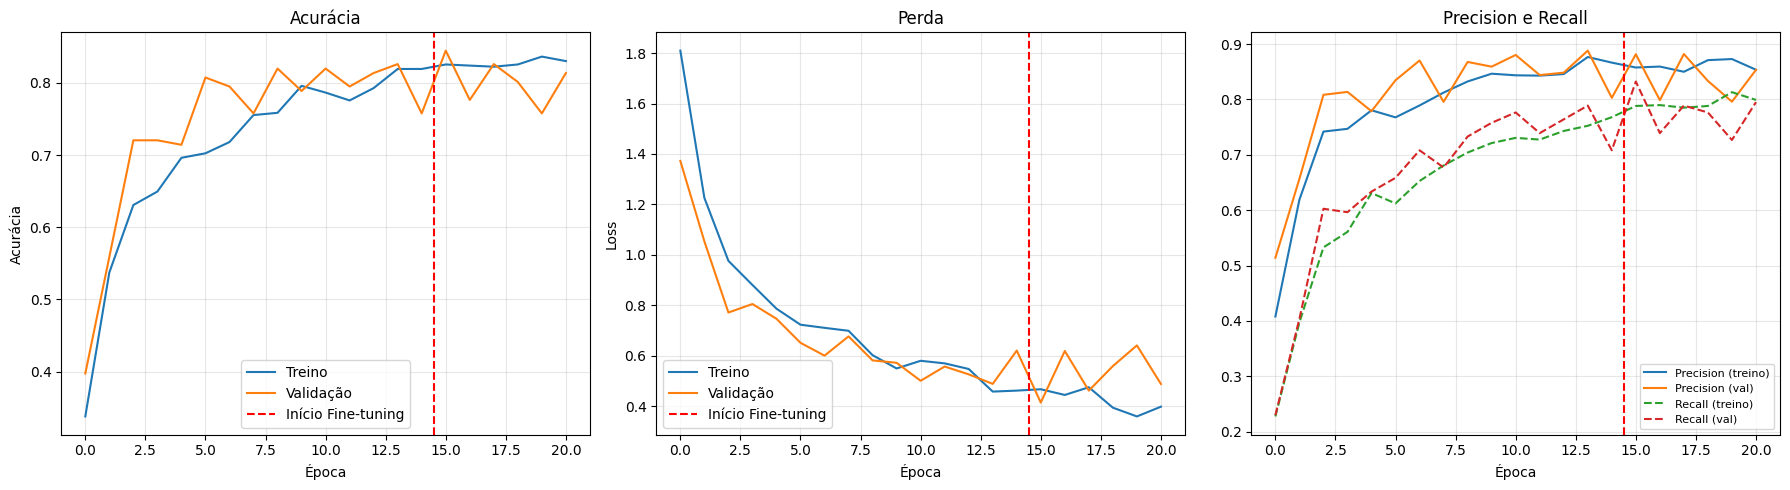

In [ ]:
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        if key in h2.history:
            combined[key] = h1.history[key] + h2.history[key]
    return combined

full_history = combine_histories(history, history_fine_tune)
fine_tune_start = len(history.history['loss'])

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(full_history['accuracy'], label='Treino')
axs[0].plot(full_history['val_accuracy'], label='Validação')
axs[0].axvline(x=fine_tune_start - 0.5, color='red', linestyle='--',
               label='Início Fine-tuning')
axs[0].set_title('Acurácia')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Acurácia')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(full_history['loss'], label='Treino')
axs[1].plot(full_history['val_loss'], label='Validação')
axs[1].axvline(x=fine_tune_start - 0.5, color='red', linestyle='--',
               label='Início Fine-tuning')
axs[1].set_title('Perda')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[2].plot(full_history['precision'], label='Precision (treino)')
axs[2].plot(full_history['val_precision'], label='Precision (val)')
axs[2].plot(full_history['recall'], label='Recall (treino)', linestyle='--')
axs[2].plot(full_history['val_recall'], label='Recall (val)', linestyle='--')
axs[2].axvline(x=fine_tune_start - 0.5, color='red', linestyle='--')
axs[2].set_title('Precision e Recall')
axs[2].set_xlabel('Época')
axs[2].legend(fontsize=8)
axs[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Célula 12 — Avaliação quantitativa global**

RELATÓRIO DE CLASSIFICAÇÃO (Validação)
                  precision    recall  f1-score   support

agriculture_land       1.00      0.83      0.91       104
     barren_land       0.73      0.92      0.81        12
     forest_land       0.95      0.90      0.92        20
          others       0.39      0.82      0.53        11
      urban_land       0.67      0.86      0.75        14

        accuracy                           0.84       161
       macro avg       0.75      0.86      0.78       161
    weighted avg       0.90      0.84      0.86       161



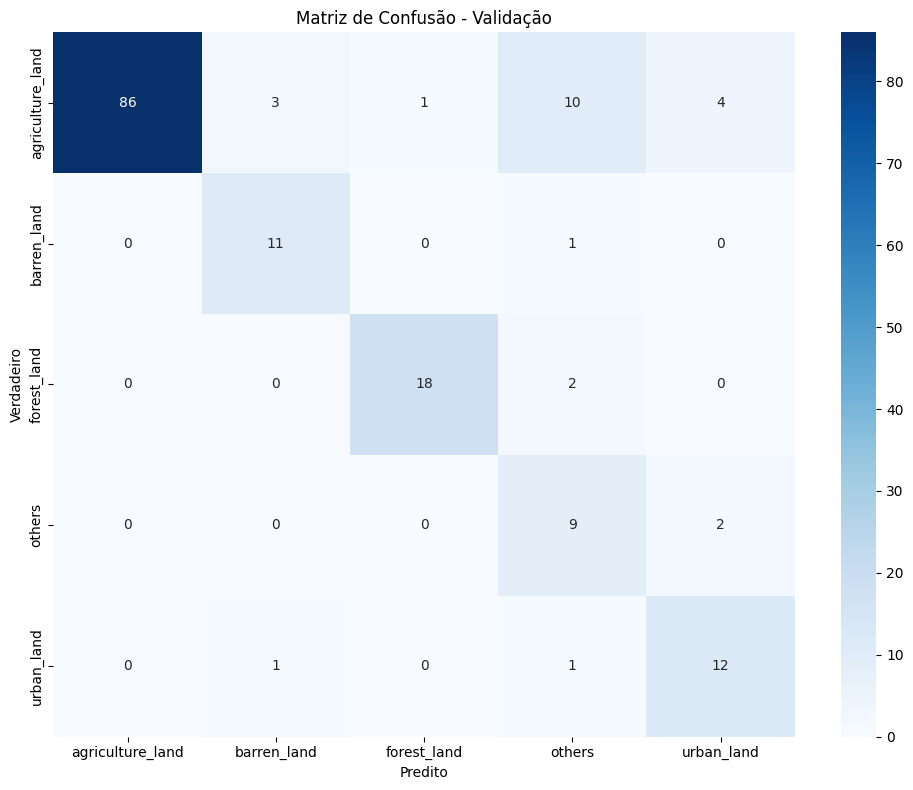

In [ ]:
y_true_all = []
y_pred_all = []

for img_batch, label_batch in val_ds:
    preds = model.predict(img_batch, verbose=0)
    y_true_all.extend(np.argmax(label_batch.numpy(), axis=1))
    y_pred_all.extend(np.argmax(preds, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

classes_in_val = sorted(set(y_true_all) | set(y_pred_all))
target_names_used = [global_class_names[i] for i in classes_in_val]

print("=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO (Validação)")
print("=" * 60)
print(classification_report(
    y_true_all, y_pred_all,
    labels=classes_in_val,
    target_names=target_names_used,
    zero_division=0
))

cm = confusion_matrix(y_true_all, y_pred_all, labels=classes_in_val)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names_used,
    yticklabels=target_names_used,
    cbar=True
)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Validação')
plt.tight_layout()
plt.show()

# **Célula 13 — Visualização qualitativa de predições**

*   Verde = Acerto
*   Vermelho = Errado

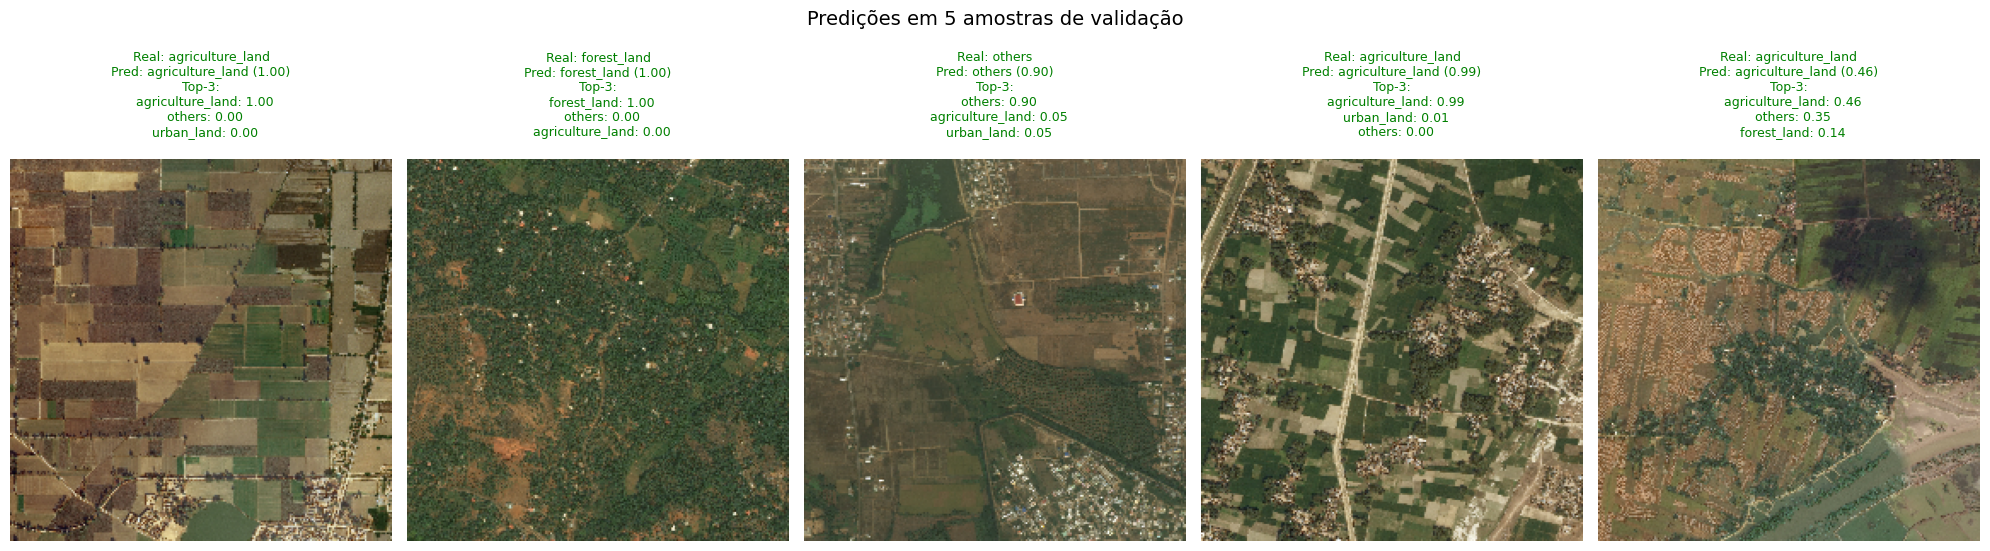

In [ ]:
def visualize_predictions(raw_dataset, model, class_names, num_samples=5, shuffle=True):
    if shuffle:
        ds = raw_dataset.unbatch().shuffle(100, seed=SEED)
    else:
        ds = raw_dataset.unbatch()

    images, labels = [], []
    for img, lbl in ds.take(num_samples):
        images.append(img.numpy())
        labels.append(lbl.numpy())
    images = np.array(images)
    labels = np.array(labels)

    images_for_pred = preprocess_input(images.copy())
    preds = model.predict(images_for_pred, verbose=0)

    fig, axs = plt.subplots(1, num_samples, figsize=(num_samples * 4, 6))
    if num_samples == 1:
        axs = [axs]

    for i in range(num_samples):
        ax = axs[i]
        ax.imshow(images[i].astype(np.uint8))
        ax.axis('off')

        true_idx = np.argmax(labels[i])
        pred_idx = np.argmax(preds[i])
        confidence = preds[i][pred_idx]

        is_correct = true_idx == pred_idx
        color = 'green' if is_correct else 'red'

        top3 = np.argsort(preds[i])[-3:][::-1]
        title = f"Real: {class_names[true_idx]}\n"
        title += f"Pred: {class_names[pred_idx]} ({confidence:.2f})\n"
        title += "Top-3:\n"
        for idx in top3:
            title += f"  {class_names[idx]}: {preds[i][idx]:.2f}\n"

        ax.set_title(title, fontsize=9, color=color)

    plt.suptitle(f"Predições em {num_samples} amostras de validação", fontsize=14, y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


visualize_predictions(val_ds_raw, model, global_class_names, num_samples=5, shuffle=True)